# Integrantes
- Marcos Vinicius Pereira de Oliveira - RM - 557252

# Nomeclatura do data set.
* age
* sex
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
- thal: 0 = normal; 1 = fixed defect; 2 = reversable defect

In [ ]:
#Utilizei o metodo apra download do dataset passado em aula, no ultimo CP consegui fazer de uma maneira bem mais complicada.
!kaggle datasets download -d johnsmith88/heart-disease-dataset
!unzip heart-disease-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
License(s): unknown
heart-disease-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  heart-disease-dataset.zip
  inflating: heart.csv               


# Importação das Bibliotecas Necessárias

In [ ]:
#Inportação das bibliotecas utilizadas.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Carregando os dados

In [ ]:
# Carregar o dataset e exibindo os 5 primeiros registros.
df = pd.read_csv('heart.csv')
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# Análise Exploratória de Dados (AED)

Vamos explorar o conjunto de dados para entender melhor suas características.

In [ ]:
#Verificando as caracteriscas do dataset escolhido para ver se a necessidade de tratar numeros nulos, verificando se todas as variaveis são do tipo texto e se é necessario remover alguma coluna.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


# Estatística Descritivas

In [ ]:
#Verificando valores e diferenças min. max. para pensar em como tratar os dados antes de dar continuidade. Podemos notar alguns valores discrepantes como chol, trestbps e thalach.
#Podemos verificar que os outros dados estão coerentes com a realidade
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# Visualização de Dados

<Axes: xlabel='target', ylabel='count'>

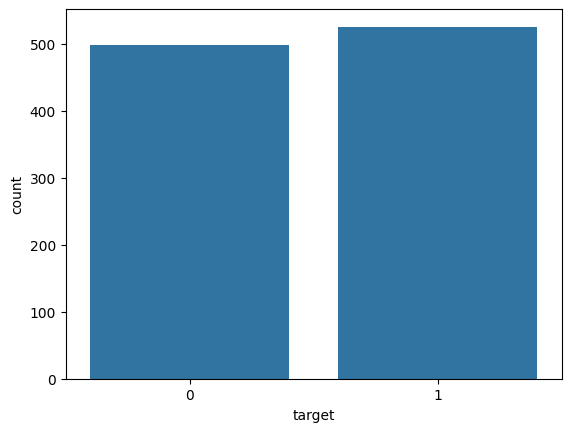

In [ ]:
# A visualização da distribuição do alvo mostra que temos uma quantidade balanceada entre as classes positiva e negativa. Esse equilíbrio é vantajoso,
# pois contribui para um treinamento mais eficaz do modelo, minimizando o risco de viés para uma classe específica.
sns.countplot(x='target', data=df)

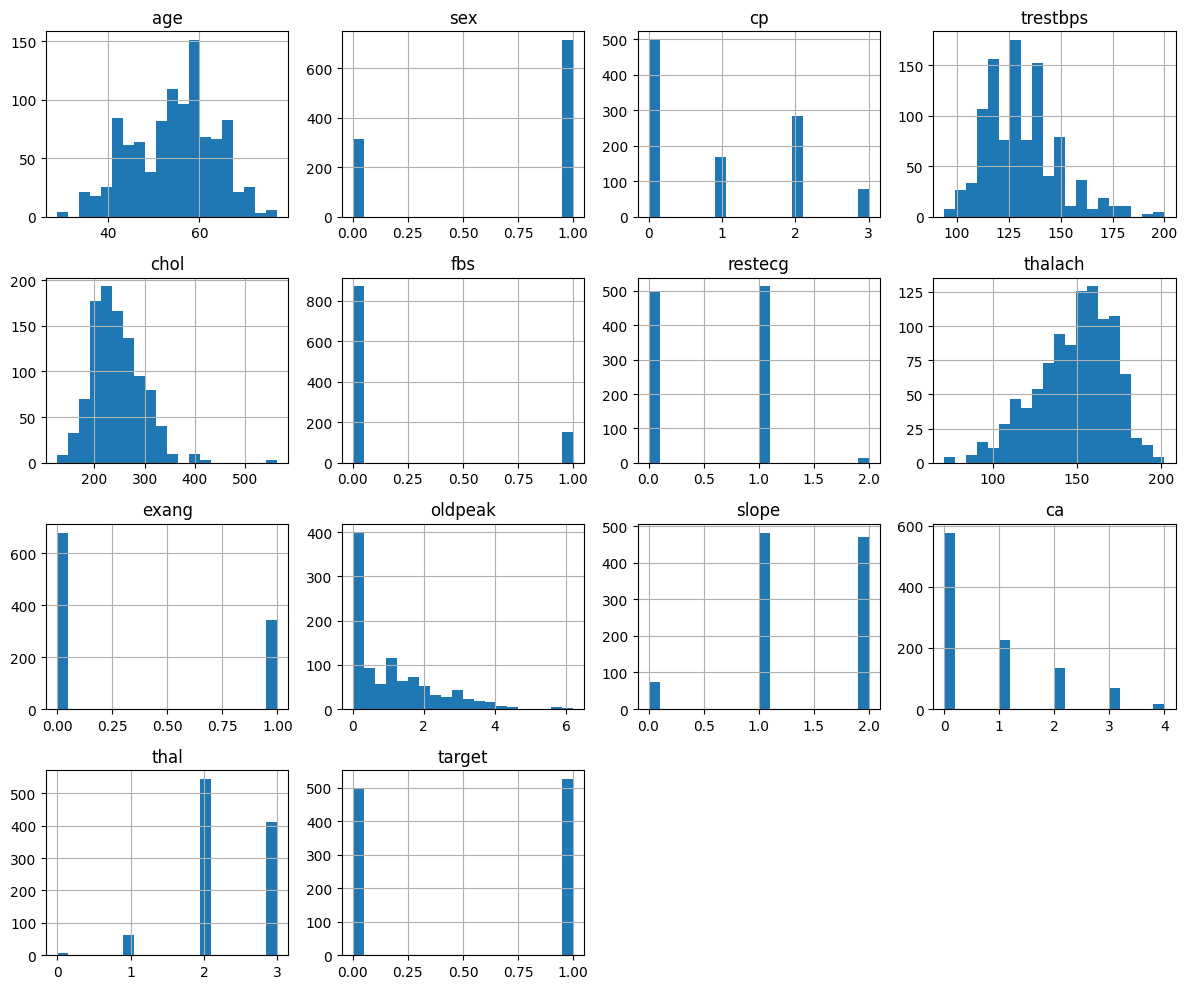

In [ ]:
# Podemos verificar a distribuição dos dados e pensar em estrategias para normalizar o mesmo.
df.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

# Divisão em Conjunto de Treino e Teste

In [ ]:
#Separado para teste 20% do dataset e exluindo a coluna target na variavel X e Y para utilizar no treino.
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



# Normalização dos Dados

Aplicamos a normalização apenas nos dados de treino e usamos os mesmos parâmetros para os dados de teste.

In [ ]:
# Lembrando de normalizar os dados separadamente utilizando os mesmos parametros.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [ ]:
# passando os dados em escala para dataframe pq queria visualizar como os dados ficaram após a normalização
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)



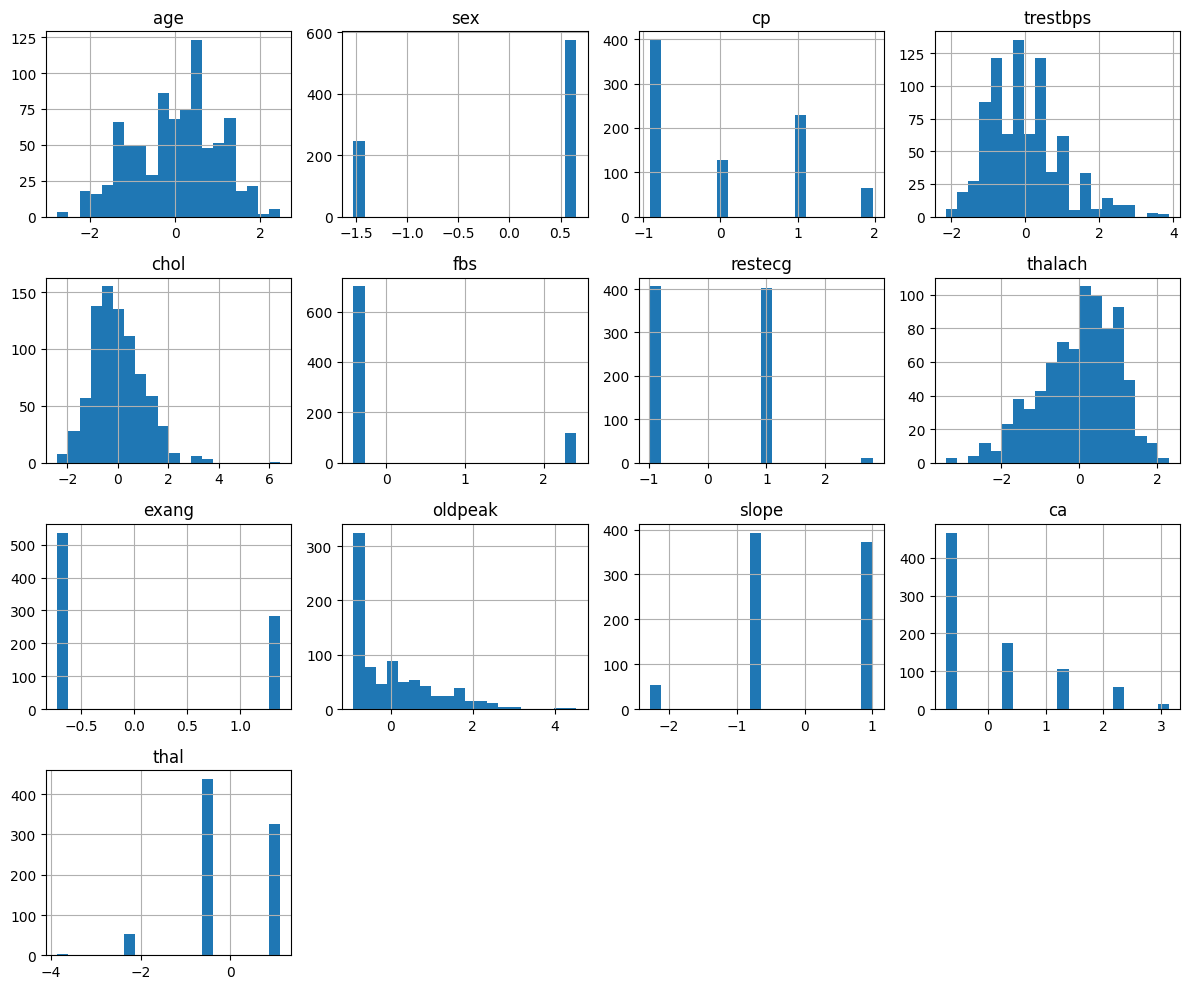

In [ ]:
# Exibindo dados normalizados
X_train_scaled_df.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

# Treinamento do Modelo SVM

In [ ]:
#Treinamento do modelo com dados tratados
from sklearn.svm import SVC

svc_model = SVC()
svc_model.fit(X_train_scaled, y_train)


SVC()

# Avaliação do Modelo

              precision    recall  f1-score   support

           0       0.93      0.83      0.88       102
           1       0.85      0.94      0.89       103

    accuracy                           0.89       205
   macro avg       0.89      0.89      0.89       205
weighted avg       0.89      0.89      0.89       205



<Axes: >

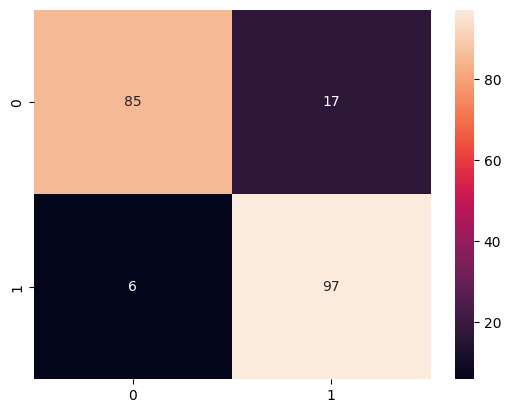

In [ ]:
#Avaliando modelo usando parametros visto em aula.

#Podemos verivicar uma boa precição tanto para negativo quando positivo, uma precição menor para negativos, como tinhamos a mesma quantidade de dados 1 e 0 talvez a diferença tenha sido
#pois os dados dos negativos sejam mais variados enquanto positivo siga melhor algum padrão (apenas uma hipotese)




from sklearn.metrics import classification_report, confusion_matrix

y_pred = svc_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)



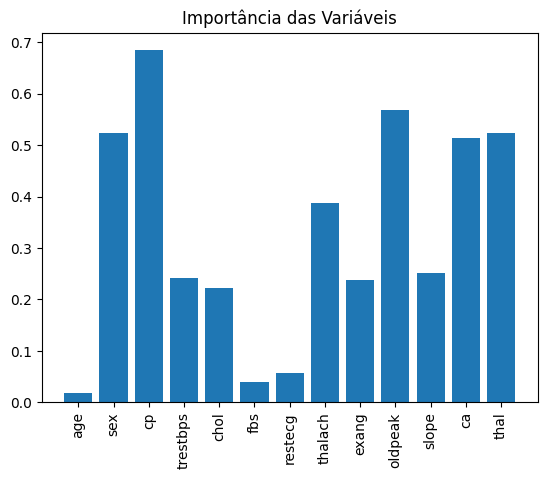

In [ ]:
# Treinamento de um modelo SVM (linear) para verificar o impacto de cada variavel na decisão do modelo.
svc_model_linear = SVC(kernel='linear')
svc_model_linear.fit(X_train_scaled, y_train)

coef = svc_model_linear.coef_[0]


plt.bar(X_train.columns, np.abs(coef))
plt.xticks(rotation=90)
plt.title('Importância das Variáveis')
plt.show()


- Dataset: Escolhi o dataset "Heart Disease" do Kaggle.
- Questão: "Quais fatores influenciam a presença de doenças cardíacas?"
- Resposta: Podemos reparar que a dor no peito (cp) é  a variável mais ingluente no modelo, juntamente com oldpeak e sex. Tambem podemos reparar que age e fbs não são tão influentes.
- Análise e Modelo: Após a análise exploratória, um modelo de classificação ou regressão poderia ser treinado para prever o risco de doenças cardíacas com base em variáveis como idade, sexo, pressão arterial, entre outras.